# 01 — EDA & Preprocessing: CICIDS2017 Network Intrusion Detection

This notebook loads the raw CICIDS2017 flow-based CSVs (CICFlowMeter output),
explores class distributions and feature characteristics, cleans the data,
and writes a processed dataset to `data/processed/` for use in the modeling
notebook.

**Dataset:** [CICIDS2017](https://www.unb.ca/cic/datasets/ids-2017.html) — Canadian
Institute for Cybersecurity, 2017. ~2.8M labeled network flows captured over
5 days, covering benign traffic and attacks: Brute Force (FTP/SSH), DoS/DDoS,
Heartbleed, Web Attacks (SQLi/XSS/Brute Force), Infiltration, Botnet, and
Port Scan.

**Before running this notebook:** download the "MachineLearningCSV"
(GeneratedLabelledFlows) zip from the link above and extract the 8 CSV files
into `data/raw/`.


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa

from data_loader import load_cicids2017
from preprocessing import clean_dataframe, add_label_columns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 1. Load raw data

Concatenates all CSV files in `data/raw/`.

In [2]:
df_raw = load_cicids2017()
df_raw.head()


Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ...
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ...
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv ...
Loading Monday-WorkingHours.pcap_ISCX.csv ...
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ...
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ...
Loading Tuesday-WorkingHours.pcap_ISCX.csv ...
Loading Wednesday-workingHours.pcap_ISCX.csv ...

Combined shape: (2830743, 80)
Files loaded: 8


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [3]:
print(f"Shape: {df_raw.shape}")
print(f"\nColumns ({df_raw.shape[1]}):")
print(list(df_raw.columns))


Shape: (2830743, 80)

Columns (80):
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count

## 2. Class distribution (raw)

CICIDS2017 is heavily imbalanced — the vast majority of flows are `BENIGN`,
with attack classes ranging from tens of thousands of rows (DoS Hulk,
PortScan, DDoS) down to single digits (Heartbleed). This imbalance drives
several of our later modeling decisions (stratified splitting, macro-F1 as
the primary metric, grouping ultra-rare classes).


Label
BENIGN                          2273097
DoS Hulk                         231073
PortScan                         158930
DDoS                             128027
DoS GoldenEye                     10293
FTP-Patator                        7938
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1966
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64


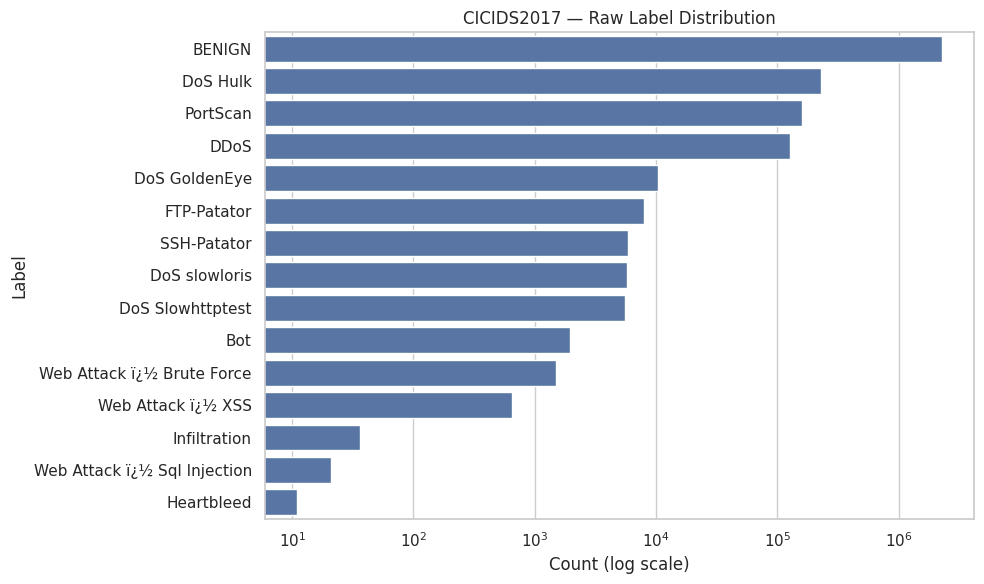

In [4]:
label_counts = df_raw["Label"].value_counts()
print(label_counts)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, ax=ax, orient="h")
ax.set_xscale("log")
ax.set_xlabel("Count (log scale)")
ax.set_title("CICIDS2017 — Raw Label Distribution")
plt.tight_layout()
plt.savefig("../outputs/figures/01_raw_label_distribution.png", dpi=150)
plt.show()


## 3. Data quality checks

Known issues in CICIDS2017's CICFlowMeter output:
- `Flow Bytes/s` and `Flow Packets/s` can be `Infinity` (division by a
  zero-duration flow).
- A non-trivial number of exact duplicate rows exist across the daily files.
- A few columns (e.g. `Fwd Header Length.1`, `Bwd Avg Bulk Rate`) are
  constant / near-constant and add no signal.

Let's quantify these before cleaning.


In [5]:
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns

n_inf = np.isinf(df_raw[numeric_cols]).sum().sum()
n_nan = df_raw[numeric_cols].isna().sum().sum()
n_dupes = df_raw.duplicated().sum()

print(f"Inf values across numeric columns: {n_inf}")
print(f"NaN values across numeric columns: {n_nan}")
print(f"Exact duplicate rows: {n_dupes} ({n_dupes / len(df_raw):.3%} of data)")


Inf values across numeric columns: 4376
NaN values across numeric columns: 1358
Exact duplicate rows: 256479 (9.060% of data)


## 4. Clean the data

Using `preprocessing.clean_dataframe`: drops inf/NaN rows, duplicates, and zero-variance columns.

In [6]:
df_clean = clean_dataframe(df_raw)
print(f"\nFinal shape: {df_clean.shape}")


Dropped 2,867 rows containing inf/NaN (0.101% of data)
Dropped 307,078 duplicate rows (10.859% of data)
Dropping 8 zero-variance columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Final shape: (2520798, 70)


## 5. Build label targets

We define two targets for the modeling notebook:
- **`label_binary`**: `BENIGN` vs `ATTACK` — the headline intrusion-detection
  task (is this traffic malicious at all?).
- **`label_multiclass`**: the specific attack category, with classes that
  have fewer than `MIN_CLASS_COUNT` samples grouped into `"Other"` so that
  stratified train/test splitting remains possible (you can't stratify a
  class with only 4 examples and put some in train and some in test).


In [7]:
df_labeled = add_label_columns(df_clean)

print(df_labeled["label_binary"].value_counts())
print()
print(df_labeled["label_multiclass"].value_counts())


Grouping 3 rare attack classes (<200 samples) into 'Other': ['Infiltration', 'Web Attack ï¿½ Sql Injection', 'Heartbleed']
label_binary
BENIGN    2095057
ATTACK     425741
Name: count, dtype: int64

label_multiclass
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack ï¿½ Brute Force       1470
Web Attack ï¿½ XSS                652
Other                              68
Name: count, dtype: int64


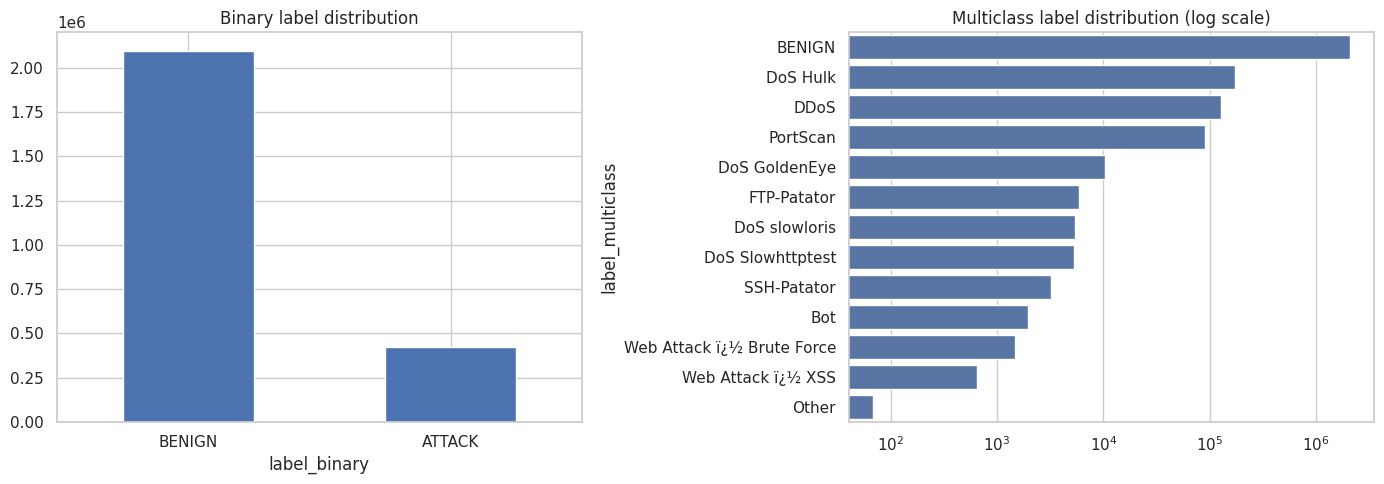

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_labeled["label_binary"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Binary label distribution")
axes[0].tick_params(axis="x", rotation=0)

mc_counts = df_labeled["label_multiclass"].value_counts()
sns.barplot(x=mc_counts.values, y=mc_counts.index, ax=axes[1], orient="h")
axes[1].set_xscale("log")
axes[1].set_title("Multiclass label distribution (log scale)")

plt.tight_layout()
plt.savefig("../outputs/figures/02_label_distributions.png", dpi=150)
plt.show()


## 6. Feature correlation overview

A quick look at correlation among numeric features — heavily correlated
features are expected (e.g. `Total Length of Fwd Packets` vs
`Subflow Fwd Bytes`), and tree-based models handle this fine, but it's
useful context for interpreting feature importances later.


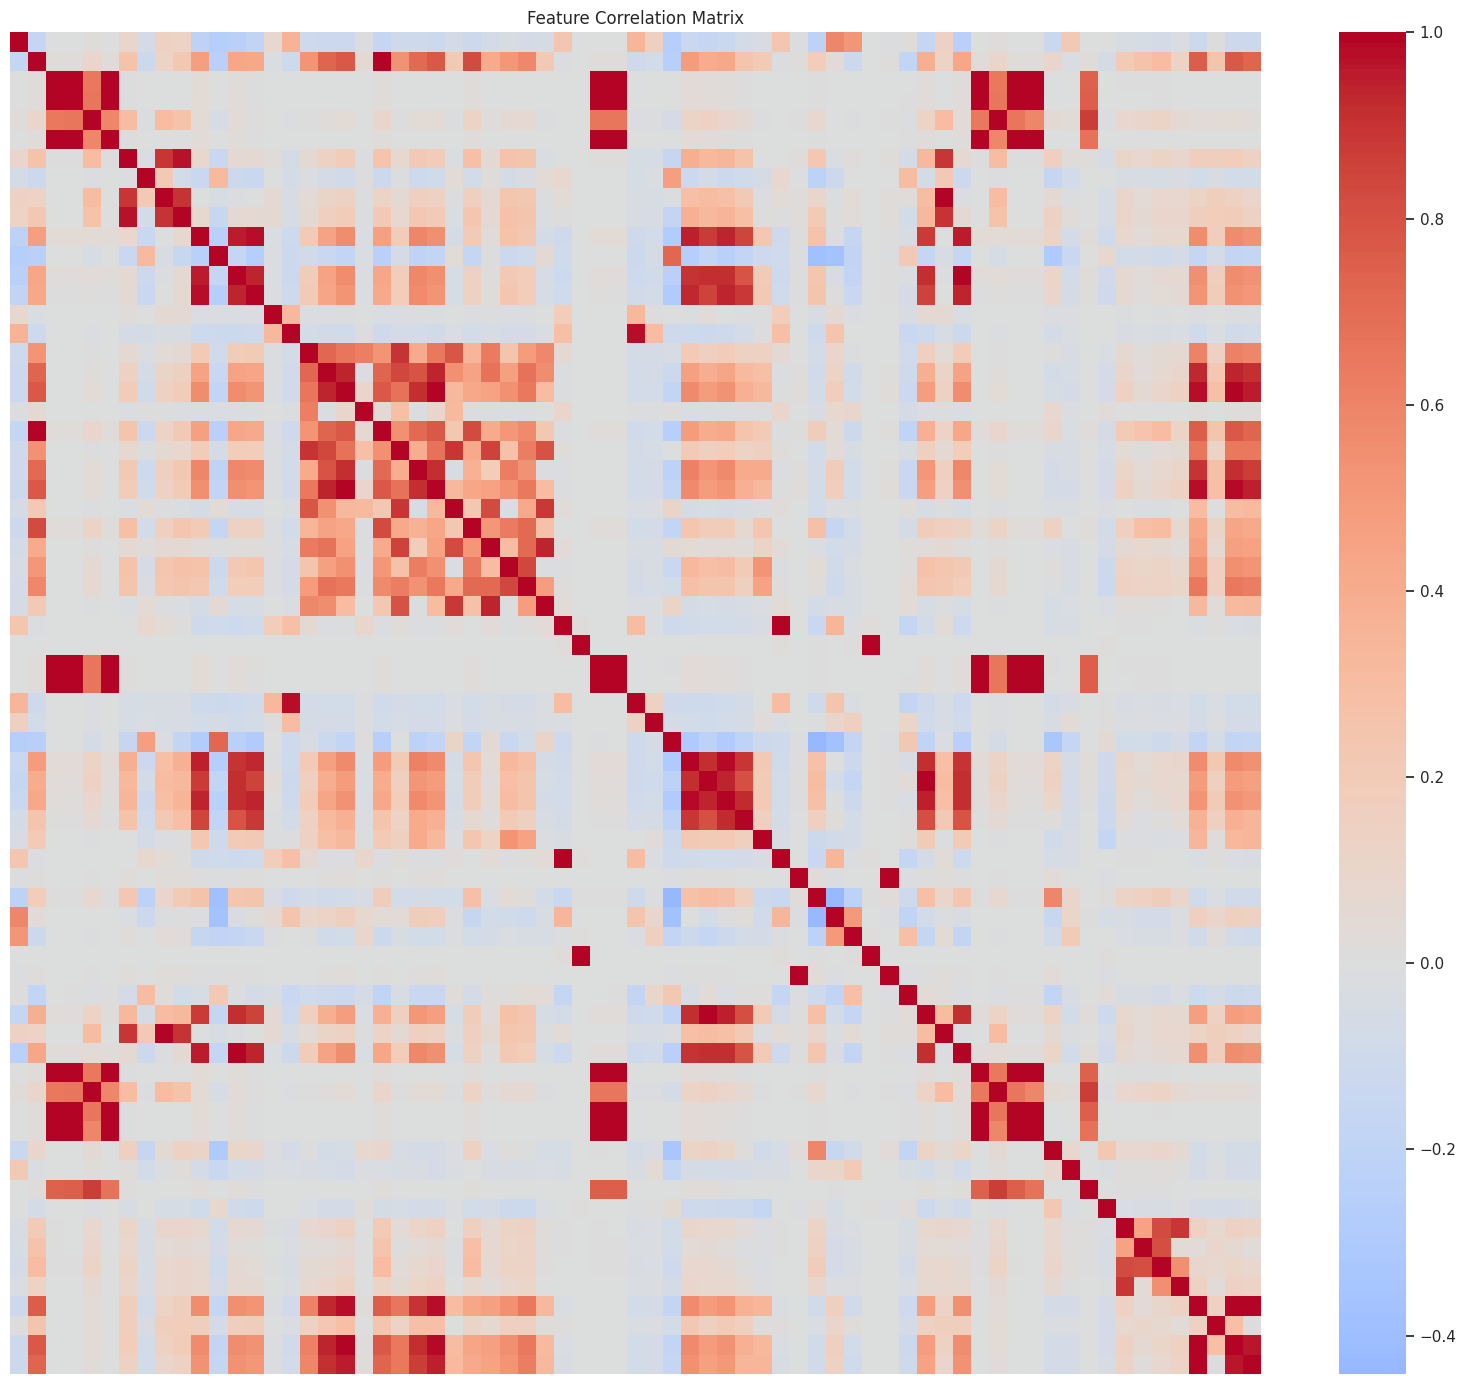

51 feature pairs with |correlation| > 0.95


,feature_1,feature_2,corr
330,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000
262,Total Backward Packets,Subflow Bwd Packets,1.000000
191,Total Fwd Packets,Subflow Fwd Packets,1.000000
2112,Fwd PSH Flags,SYN Flag Count,1.000000
2186,Fwd URG Flags,CWE Flag Count,1.000000
880,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000
3015,RST Flag Count,ECE Flag Count,1.000000
603,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000
401,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000
240,Total Backward Packets,Bwd Header Length,0.999968


In [9]:
numeric_cols = df_labeled.select_dtypes(include=[np.number]).columns
corr = df_labeled[numeric_cols].sample(n=min(50000, len(df_labeled)), random_state=42).corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax,
            xticklabels=False, yticklabels=False)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/03_correlation_heatmap.png", dpi=150)
plt.show()

# Highly correlated pairs (|r| > 0.95)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={0: "corr", "level_0": "feature_1", "level_1": "feature_2"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["corr"].abs() > 0.95]
print(f"{len(high_corr_pairs)} feature pairs with |correlation| > 0.95")
high_corr_pairs.sort_values("corr", key=abs, ascending=False).head(10)


## 7. Distribution of a few key features by label

Sanity check: do attack flows actually look different from benign flows on
some intuitive features? (e.g. PortScan should have very short/zero-payload
flows; DoS Hulk should have high packet rates.)


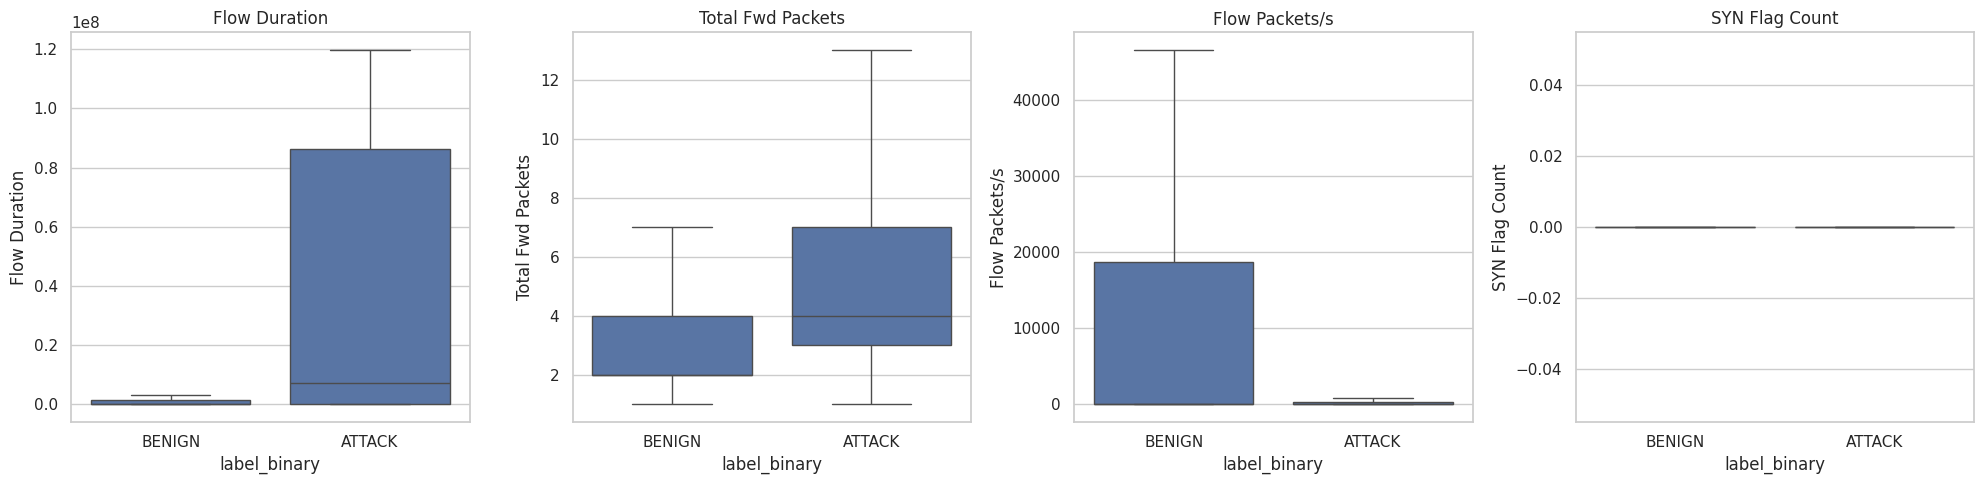

In [10]:
key_features = ["Flow Duration", "Total Fwd Packets", "Flow Packets/s",
                 "SYN Flag Count"]
key_features = [c for c in key_features if c in df_labeled.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(5 * len(key_features), 5))
for ax, feat in zip(axes, key_features):
    sample = df_labeled.sample(n=min(20000, len(df_labeled)), random_state=1)
    sns.boxplot(data=sample, x="label_binary", y=feat, ax=ax, showfliers=False)
    ax.set_title(feat.strip())

plt.tight_layout()
plt.savefig("../outputs/figures/04_feature_distributions.png", dpi=150)
plt.show()


## 8. Save processed data

Written to `data/processed/cicids2017_clean.parquet` for the modeling notebook.

In [11]:
import os
os.makedirs("../data/processed", exist_ok=True)
df_labeled.to_parquet("../data/processed/cicids2017_clean.parquet", index=False)
print(f"Saved {df_labeled.shape[0]:,} rows x {df_labeled.shape[1]} columns")


Saved 2,520,798 rows x 72 columns
